# University Website Quality Scoring and Ranking

**Machine Learning Laboratory — CSE 4112**
Department of Computer Science and Engineering
Khulna University of Engineering & Technology

---

## What this notebook does

Given the measurable attributes of a university's landing page, predict a **website quality
score from 0 to 100** — higher is better — and rank 1,225 universities globally, by region
and by country.

```
    INPUT                        MODEL                    OUTPUT
 71 measured           ->   trained regressor    ->   score 0-100
 attributes of                                        grade A+ .. F
 one landing page                                     global / regional / country rank
```

## How the notebook is organised

| § | Section | What it establishes |
|---|---|---|
| 1 | Data | 1,225 universities, 71 attributes, how they were cleaned |
| 2 | Exploration | what the attributes look like, what is missing and why |
| 3 | The scoring model | the seven-dimension equation that defines the target |
| 4 | Train / test split | 80 / 20, stratified, fixed seed |
| 5 | **Model comparison** | twelve algorithms on identical data — the main experiment |
| 6 | Cross-validation | confirming the ranking of models is not a fluke of one split |
| 7 | Tuning | grid search on the winner |
| 8 | Held-out evaluation | the final honest number |
| 9 | Why models differ | error analysis — the result worth presenting |
| 10 | Feature importance | what actually drives a website's score |
| 11 | Rankings | global, regional, country |
| 12 | **Look up any university** | interactive |
| 13 | **Score a new university** | interactive |
| 14 | Conclusions and limitations | |

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (ExtraTreesRegressor, GradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})

HERE = Path.cwd()
BASE = HERE.parent if HERE.name == "notebook" else HERE
DATA = BASE / "data"

print(f"project root : {BASE}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | lightgbm {lgb.__version__}")

project root : C:\Users\USER\OneDrive\Desktop\ML_PROJECT\FINAL_PROJECT
numpy 2.4.4 | pandas 2.3.3 | lightgbm 4.6.0


---
# 1. The data

The raw crawl covered 1,230 university landing pages with 85 columns. Cleaning is performed
by `src/build_dataset.py` and is fully reproducible; the log below is what it did.

| step | effect |
|---|---|
| dropped constant / empty columns | `ok`, `extractor_version`, `render_error` |
| dropped an exact duplicate column | `a62_load_speed_s` was identical to `load_time_s` |
| dropped external ranking *values* | 95–99% missing, and they describe the institution, not the site |
| merged duplicate sites | 5 universities reached through two entry URLs each → 1,225 rows |
| censored impossible dates | 284 notice dates fell *after* the crawl date |
| flagged regional buckets | 169 rows have a region in the `country` field, not a country |

The three CSV files below are the entire dataset.

In [2]:
full = pd.read_csv(DATA / "university_website_scores.csv")
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
ddict = pd.read_csv(DATA / "data_dictionary.csv")
summary = json.loads((DATA / "dataset_summary.json").read_text(encoding="utf-8"))

META = ["uni_id", "name", "url", "country", "region", "rank", "regional_rank", "country_rank"]
TARGET = "website_score"
FEATURES = [c for c in train.columns if c not in META + [TARGET, "grade"]]

print(f"all universities : {len(full):,} rows x {len(FEATURES)} features")
print(f"training set     : {len(train):,} rows  ({len(train)/len(full):.0%})")
print(f"test set         : {len(test):,} rows  ({len(test)/len(full):.0%})")
print(f"\nno overlap between train and test: {len(set(train.uni_id) & set(test.uni_id)) == 0}")
full.head(4)[["rank", "name", "country", "a37_programs_listing",
              "a34_department_links", "a03_nav_item_count", "website_score", "grade"]]

all universities : 1,225 rows x 71 features
training set     : 979 rows  (80%)
test set         : 246 rows  (20%)

no overlap between train and test: True


,rank,name,country,a37_programs_listing,a34_department_links,a03_nav_item_count,website_score,grade
0,1,University of New England,Australia,1,1,6,95.39,A+
1,2,University of Porto,Portugal,1,1,5,94.98,A+
2,3,Eotvos Lorand University,Hungary,1,1,5,94.95,A+
3,4,University of Strasbourg,France,1,1,6,94.31,A+


## What the 71 features are

Every feature is something that can be measured automatically from the landing page: a
presence flag (does a programmes page exist), a count (how many menu items), or a
measurement (contrast ratio, mobile score, load time).

In [3]:
groups = ddict[ddict.role == "feature"].dimension.value_counts()
print("features by the dimension they inform:\n")
for dim, n in groups.items():
    print(f"  {dim:<42} {n:>3}")
print(f"\n  {'TOTAL':<42} {groups.sum():>3}")

features by the dimension they inform:

  not used by the scoring model               34
  D4 navigation                                6
  D5 usability & access                        6
  D1 academic information                      6
  D7 transparency                              5
  D2 admission support                         5
  D6 technical quality                         5
  D3 currency & activity                       4

  TOTAL                                       71


---
# 2. Exploring the data

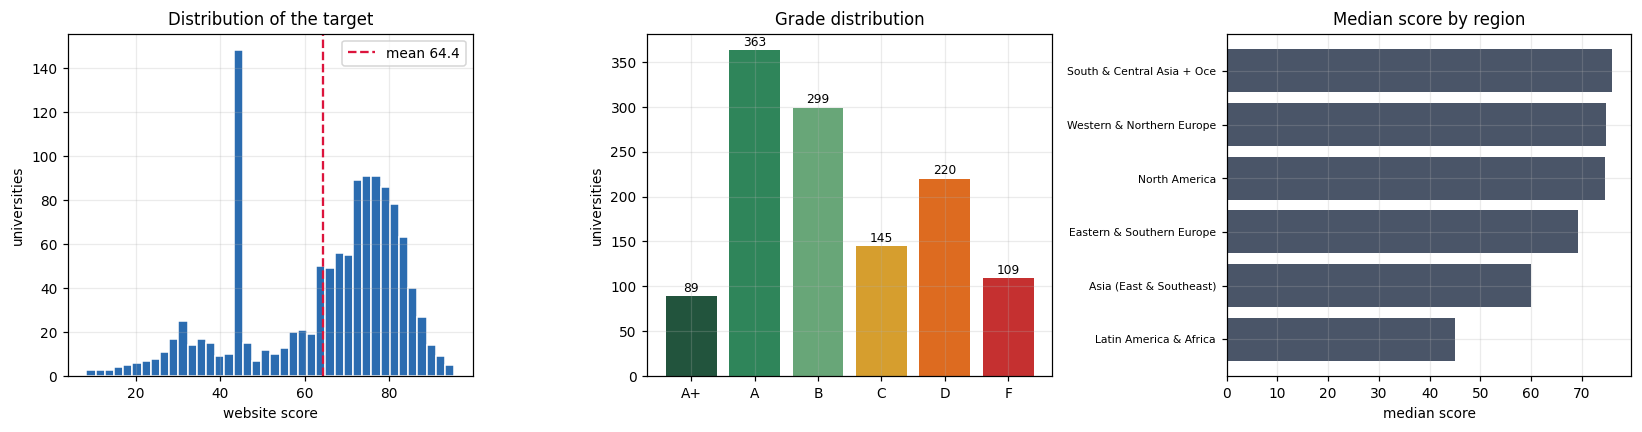

count    1225.00
mean       64.43
std        18.40
min         8.33
25%        45.58
50%        70.71
75%        78.33
max        95.39


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(full.website_score, bins=40, color="#2b6cb0", edgecolor="white")
ax[0].axvline(full.website_score.mean(), color="crimson", ls="--", lw=1.5,
              label=f"mean {full.website_score.mean():.1f}")
ax[0].set_xlabel("website score"); ax[0].set_ylabel("universities")
ax[0].set_title("Distribution of the target"); ax[0].legend()

order = ["A+", "A", "B", "C", "D", "F"]
gc = full.grade.value_counts().reindex(order)
ax[1].bar(order, gc.values, color=["#22543d", "#2f855a", "#68a678", "#d69e2e", "#dd6b20", "#c53030"])
for i, v in enumerate(gc.values):
    ax[1].text(i, v + 5, str(v), ha="center", fontsize=8)
ax[1].set_title("Grade distribution"); ax[1].set_ylabel("universities")

reg = full.groupby("region").website_score.median().sort_values()
ax[2].barh(range(len(reg)), reg.values, color="#4a5568")
ax[2].set_yticks(range(len(reg)))
ax[2].set_yticklabels([r[:26] for r in reg.index], fontsize=7)
ax[2].set_xlabel("median score"); ax[2].set_title("Median score by region")
plt.tight_layout(); plt.show()

print(full.website_score.describe().round(2).to_string())

The target has a long left tail and a visible shoulder around 45. That shoulder is not an
artefact — it is the population of sites that hit a **scoring gate** (§3), and it is the
structure that separates the model families in §5.

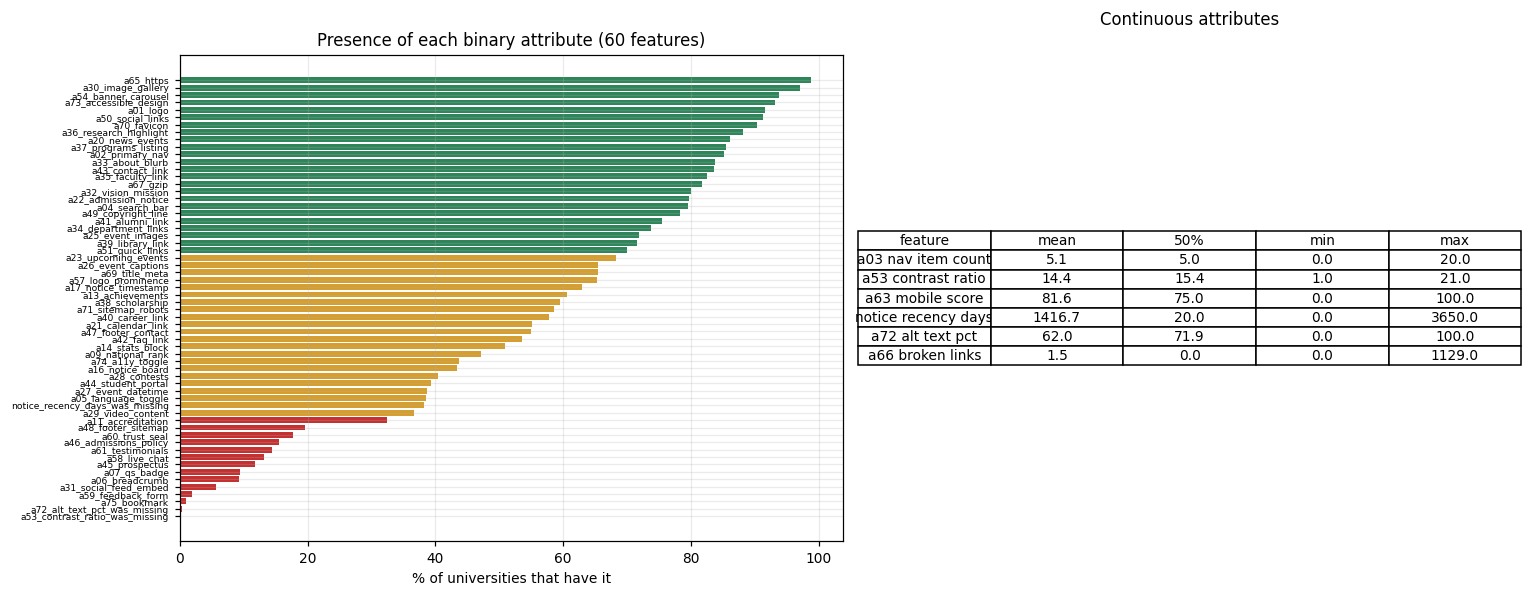

In [5]:
binaries = [c for c in FEATURES if full[c].dropna().isin([0, 1]).all() and full[c].nunique() == 2]
prev = full[binaries].mean().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ["#c53030" if v < 0.35 else "#d69e2e" if v < 0.7 else "#2f855a" for v in prev.values]
ax[0].barh(range(len(prev)), prev.values * 100, color=colors)
ax[0].set_yticks(range(len(prev))); ax[0].set_yticklabels(prev.index, fontsize=6)
ax[0].set_xlabel("% of universities that have it")
ax[0].set_title(f"Presence of each binary attribute ({len(prev)} features)")

num = ["a03_nav_item_count", "a53_contrast_ratio", "a63_mobile_score",
       "notice_recency_days", "a72_alt_text_pct", "a66_broken_links"]
ax[1].axis("off")
tbl = full[num].describe().T[["mean", "50%", "min", "max"]].round(1)
tbl.insert(0, "feature", [n.replace("_", " ") for n in tbl.index])
ax[1].table(cellText=tbl.values, colLabels=tbl.columns, loc="center", cellLoc="center"
            ).auto_set_font_size(False)
ax[1].set_title("Continuous attributes", pad=20)
plt.tight_layout(); plt.show()

## Missing values: absence has a direction

Three attributes are missing for some sites, and the standard fix — replace with the median
— is wrong for all three.

The clearest case is `notice_recency_days`. Its median is **1 day**. Median-filling would
therefore record the **468 universities with no dated notice anywhere on the site** as
having posted something *yesterday*, handing the strongest freshness signal in the dataset
to exactly the sites that earned it least. Absence would be read as average when it means
*absent*.

Each of the three is filled at its **worst defensible value** instead, and a companion
`*_was_missing` flag is computed first, so "this was never measured" stays recoverable.

In [6]:
policy = json.loads((DATA / "missing_value_policy.json").read_text(encoding="utf-8"))
print(f"{'attribute':<26}{'rows':>6}{'filled with':>13}{'median would be':>17}   meaning of absence")
for k, v in policy.items():
    print(f"{k:<26}{v['n_filled']:>6}{v['fill_value']:>13.1f}{v['median_would_have_been']:>17.1f}"
          f"   {v['reason'].split('->')[0].strip()}")

attribute                   rows  filled with  median would be   meaning of absence
notice_recency_days          468       3650.0              1.0   no dated notice exists anywhere
a72_alt_text_pct               4          0.0             72.0   no image carries a text alternative
a53_contrast_ratio             1          1.0             15.4   no readable text block was found


---
# 3. The scoring model

The dataset records what a website *has*. It does not record how good it is, so a scoring
model was defined to turn attributes into a score. It is built around one question:

> **What does a prospective student need from a university website?**

Seven dimensions answer that question. Each is a sub-score in $[0, 1]$ built from named
attributes; the website score is their weighted sum, subject to two gates:

$$
\text{Score} \;=\; \min\Bigl(\textstyle\sum_{k=1}^{7} w_k D_k,\; \text{cap}\Bigr)
$$

| | Dimension | Weight | What it asks |
|---|---|---|---|
| $D_1$ | Academic information | **28** | What can I study, and who teaches it? |
| $D_2$ | Admission support | **22** | How do I apply, and what will it cost? |
| $D_3$ | Currency and activity | **15** | Is this institution alive and current? |
| $D_4$ | Navigation and findability | **15** | Can I find what I need? |
| $D_5$ | Usability and accessibility | **10** | Can I use it, on any device? |
| $D_6$ | Technical quality | **7** | Does the site actually work? |
| $D_7$ | Institutional transparency | **3** | Is it clear who they are? |

The weights are ordered by how directly each dimension serves the applicant's task.
Content a student came for carries half the score ($D_1 + D_2 = 50$); the machinery that
delivers it carries most of the rest; self-presentation carries the least.

### Two gates

Some failures are severe enough to cap the score regardless of everything else:

* **no primary navigation → score capped at 45.** A site that cannot be navigated cannot
  serve an applicant, however much content is buried in it.
* **no HTTPS → score capped at 60.** A site that is not encrypted should not be trusted
  with an application form.

### Non-linear response curves

Four attributes do not reward linearly, and the scoring model says so explicitly. These
curves are the reason §5 finds a real difference between model families.

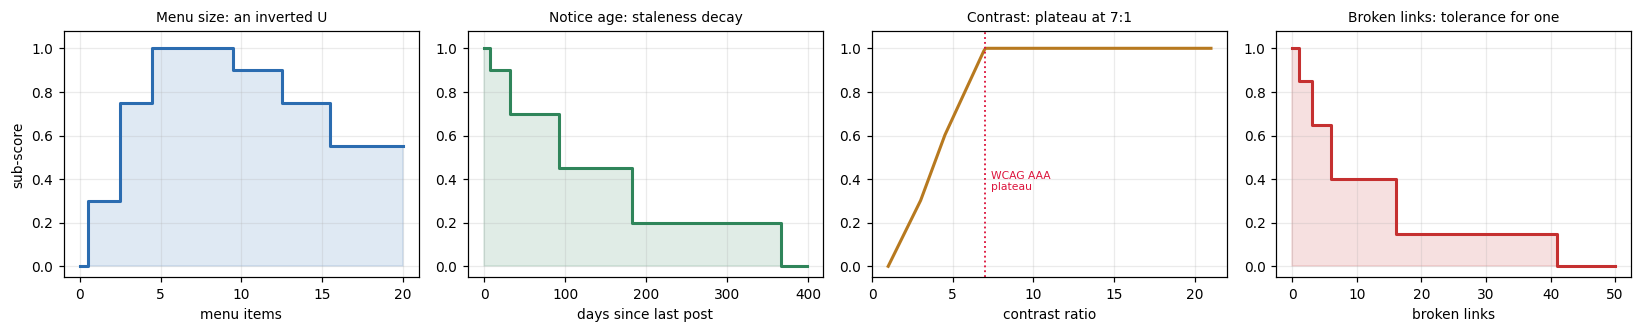

Why these shapes matter for the modelling:

  menu size   a 20-item menu is a wall of links, not better navigation than a 7-item menu.
              No monotone (always-increasing) function can express that.
  notice age  a post from last week and one from last year are not 51 weeks apart in value;
              both "recent" and "abandoned" are plateaus with a cliff between them.
  contrast    WCAG AAA is 7:1. Beyond it, more contrast is not a better reading experience,
              so the curve stops rewarding rather than continuing upward.
  broken      one dead link is an oversight, forty is neglect. The penalty is not linear
  links       in the count.


In [7]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.1))

n = np.arange(0, 21)
nav = np.where(n <= 0, 0, np.where(n <= 2, .3, np.where(n <= 4, .75,
      np.where(n <= 9, 1., np.where(n <= 12, .9, np.where(n <= 15, .75, .55))))))
ax[0].step(n, nav, where="mid", color="#2b6cb0", lw=2)
ax[0].fill_between(n, nav, step="mid", alpha=.15, color="#2b6cb0")
ax[0].set_title("Menu size: an inverted U", fontsize=9)
ax[0].set_xlabel("menu items"); ax[0].set_ylabel("sub-score")

d = np.arange(0, 400, 2)
rec = np.where(d <= 7, 1., np.where(d <= 30, .9, np.where(d <= 90, .7,
      np.where(d <= 180, .45, np.where(d <= 365, .2, 0.)))))
ax[1].step(d, rec, where="post", color="#2f855a", lw=2)
ax[1].fill_between(d, rec, step="post", alpha=.15, color="#2f855a")
ax[1].set_title("Notice age: staleness decay", fontsize=9); ax[1].set_xlabel("days since last post")

r = np.linspace(1, 21, 200)
con = np.where(r < 3, (r - 1) / 2 * .3, np.where(r < 4.5, .3 + (r - 3) / 1.5 * .3,
      np.where(r < 7, .6 + (r - 4.5) / 2.5 * .4, 1.)))
ax[2].plot(r, con, color="#b7791f", lw=2)
ax[2].axvline(7, color="crimson", ls=":", lw=1.2)
ax[2].text(7.4, .35, "WCAG AAA\nplateau", fontsize=7, color="crimson")
ax[2].set_title("Contrast: plateau at 7:1", fontsize=9); ax[2].set_xlabel("contrast ratio")

b = np.arange(0, 51)
bro = np.where(b <= 0, 1., np.where(b <= 2, .85, np.where(b <= 5, .65,
      np.where(b <= 15, .4, np.where(b <= 40, .15, 0.)))))
ax[3].step(b, bro, where="post", color="#c53030", lw=2)
ax[3].fill_between(b, bro, step="post", alpha=.15, color="#c53030")
ax[3].set_title("Broken links: tolerance for one", fontsize=9); ax[3].set_xlabel("broken links")

for a in ax:
    a.set_ylim(-.05, 1.08)
plt.tight_layout(); plt.show()

print("""Why these shapes matter for the modelling:

  menu size   a 20-item menu is a wall of links, not better navigation than a 7-item menu.
              No monotone (always-increasing) function can express that.
  notice age  a post from last week and one from last year are not 51 weeks apart in value;
              both "recent" and "abandoned" are plateaus with a cliff between them.
  contrast    WCAG AAA is 7:1. Beyond it, more contrast is not a better reading experience,
              so the curve stops rewarding rather than continuing upward.
  broken      one dead link is an oversight, forty is neglect. The penalty is not linear
  links       in the count.""")

## What the scoring model produced

scoring gates applied to 186 of 1225 universities (15.2%)

  no primary navigation (cap 45) :  182
  no HTTPS              (cap 60) :   14


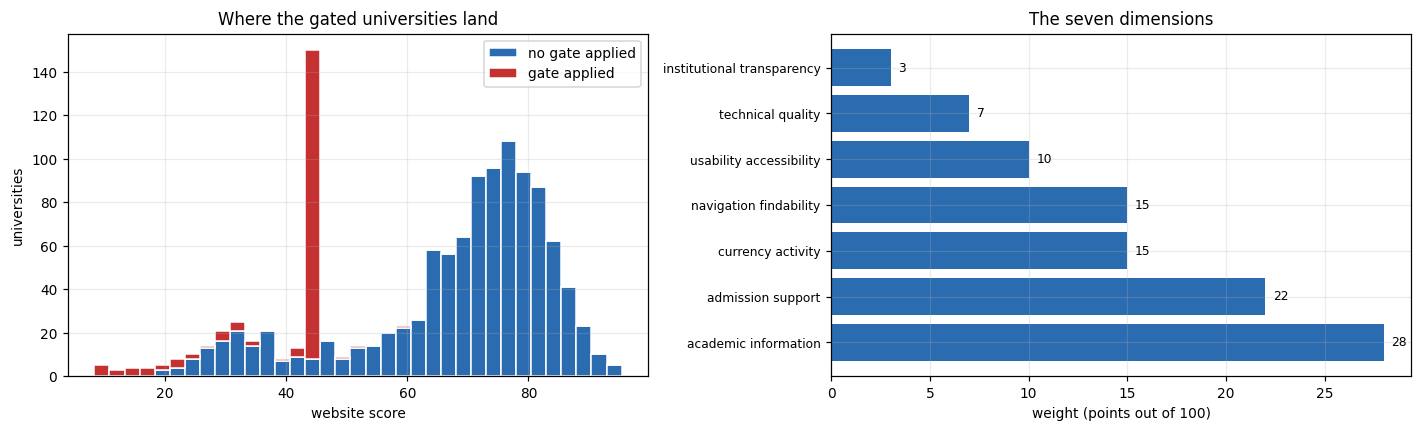

In [8]:
DIMS = {"D1_academic_information": 28, "D2_admission_support": 22, "D3_currency_activity": 15,
        "D4_navigation_findability": 15, "D5_usability_accessibility": 10,
        "D6_technical_quality": 7, "D7_institutional_transparency": 3}

gated = ((full.a02_primary_nav == 0) | (full.a65_https == 0))
print(f"scoring gates applied to {gated.sum()} of {len(full)} universities "
      f"({gated.mean():.1%})\n")
print(f"  no primary navigation (cap 45) : {(full.a02_primary_nav == 0).sum():>4}")
print(f"  no HTTPS              (cap 60) : {(full.a65_https == 0).sum():>4}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist([full.website_score[~gated], full.website_score[gated]], bins=35, stacked=True,
           color=["#2b6cb0", "#c53030"], edgecolor="white",
           label=["no gate applied", "gate applied"])
ax[0].set_xlabel("website score"); ax[0].set_ylabel("universities")
ax[0].set_title("Where the gated universities land"); ax[0].legend()

w = pd.Series(DIMS)
ax[1].barh(range(len(w)), w.values, color="#2b6cb0")
ax[1].set_yticks(range(len(w)))
ax[1].set_yticklabels([k.split("_", 1)[1].replace("_", " ") for k in w.index], fontsize=8)
ax[1].set_xlabel("weight (points out of 100)")
ax[1].set_title("The seven dimensions")
for i, v in enumerate(w.values):
    ax[1].text(v + .4, i, str(v), va="center", fontsize=8)
plt.tight_layout(); plt.show()

---
# 4. Train / test split

**80% train, 20% test**, stratified on score band so both halves span the full quality
range, with a fixed seed so the split is reproducible.

The test set is used **once**, in §8. No model, hyper-parameter or threshold is chosen
using it.

In [9]:
X_tr, y_tr = train[FEATURES], train[TARGET].values
X_te, y_te = test[FEATURES], test[TARGET].values

print(f"{'':10}{'n':>7}{'mean':>9}{'sd':>8}{'min':>8}{'max':>8}")
for nm, yy in [("train", y_tr), ("test", y_te)]:
    print(f"{nm:10}{len(yy):>7}{yy.mean():>9.2f}{yy.std():>8.2f}{yy.min():>8.1f}{yy.max():>8.1f}")

band = pd.concat([train.assign(split="train"), test.assign(split="test")])
band["score_band"] = pd.cut(band.website_score, [-1, 35, 50, 65, 75, 85, 101],
                            labels=["<35", "35-50", "50-65", "65-75", "75-85", "85+"])
print("\nstratification held:")
print(pd.crosstab(band.score_band, band.split, normalize="columns").mul(100).round(1).to_string())

                n     mean      sd     min     max
train         979    64.44   18.30     9.1    95.4
test          246    64.39   18.76     8.3    95.0

stratification held:
split       test  train
score_band             
<35          8.9    8.9
35-50       17.9   18.0
50-65       11.8   11.8
65-75       24.4   24.4
75-85       29.7   29.7
85+          7.3    7.2


---
# 5. Model comparison — the main experiment

Twelve algorithms, identical training data, identical test data, no tuning yet. Scaling is
applied inside a pipeline for the distance- and gradient-based methods that need it, and
never for the tree methods, which do not.

Metrics: **R²** (variance explained), **MAE** (average error in score points), **RMSE**
(penalises large errors), **Spearman ρ** (does it get the *ranking* right — the deliverable
here is a league table, so this is the one that matters most).

In [10]:
def scaled(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])

MODELS = {
    "Mean baseline":      DummyRegressor(strategy="mean"),
    "Linear Regression":  scaled(LinearRegression()),
    "Ridge":              scaled(Ridge(alpha=1.0)),
    "Lasso":              scaled(Lasso(alpha=0.1)),
    "k-NN (k=5)":         scaled(KNeighborsRegressor(n_neighbors=5)),
    "SVR (RBF kernel)":   scaled(SVR(C=100, gamma="scale")),
    # The MLP is the only model here that needs the TARGET scaled as well as the inputs.
    # On the raw 0-100 scale one fold in five diverges and cross-validated R2 collapses to
    # -0.03 +/- 1.88. Wrapping it in a TransformedTargetRegressor and adding L2 (alpha)
    # makes it stable at 0.94 +/- 0.04.
    "Neural Net (MLP)":   TransformedTargetRegressor(
                              scaled(MLPRegressor(hidden_layer_sizes=(128, 64), alpha=1e-2,
                                                  max_iter=4000, early_stopping=True,
                                                  n_iter_no_change=40, random_state=0)),
                              transformer=StandardScaler()),
    "Decision Tree":      DecisionTreeRegressor(random_state=0),
    "Extra Trees":        ExtraTreesRegressor(n_estimators=400, random_state=0, n_jobs=-1),
    "Random Forest":      RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=0),
    "LightGBM":           lgb.LGBMRegressor(n_estimators=600, learning_rate=0.05,
                                            num_leaves=31, random_state=0, verbose=-1),
}

FAMILY = {"Mean baseline": "baseline", "Linear Regression": "linear", "Ridge": "linear",
          "Lasso": "linear", "k-NN (k=5)": "instance", "SVR (RBF kernel)": "kernel",
          "Neural Net (MLP)": "neural", "Decision Tree": "tree", "Extra Trees": "ensemble",
          "Random Forest": "ensemble", "Gradient Boosting": "ensemble", "LightGBM": "ensemble"}

rows, fitted, preds = [], {}, {}
for name, model in MODELS.items():
    model.fit(X_tr, y_tr)
    p = model.predict(X_te)
    fitted[name], preds[name] = model, p
    rows.append(dict(model=name, family=FAMILY[name],
                     R2=r2_score(y_te, p),
                     MAE=mean_absolute_error(y_te, p),
                     RMSE=float(np.sqrt(np.mean((y_te - p) ** 2))),
                     Spearman=stats.spearmanr(y_te, p).statistic if p.std() > 0 else 0.0))

comparison = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
comparison.index += 1
print(comparison.to_string(float_format=lambda v: f"{v:.3f}"))

BEST = comparison.iloc[0].model
print(f"\nbest by R2 on the held-out test set: {BEST}")
print()
print("One practical note. The MLP was the only model that needed the TARGET scaled as well")
print("as the inputs -- on the raw 0-100 scale one fold in five diverged. Tree models needed")
print("no such care, which is part of why they are the practical choice at this data size.")

                model    family     R2    MAE   RMSE  Spearman
1            LightGBM  ensemble  0.992  1.256  1.708     0.992
2   Gradient Boosting  ensemble  0.989  1.505  1.935     0.990
3    Neural Net (MLP)    neural  0.985  1.722  2.265     0.984
4       Random Forest  ensemble  0.971  2.352  3.216     0.969
5    SVR (RBF kernel)    kernel  0.961  2.479  3.719     0.979
6   Linear Regression    linear  0.959  2.565  3.796     0.984
7               Ridge    linear  0.959  2.604  3.799     0.984
8               Lasso    linear  0.956  2.822  3.928     0.983
9         Extra Trees  ensemble  0.945  3.129  4.413     0.939
10      Decision Tree      tree  0.915  3.781  5.466     0.926
11         k-NN (k=5)  instance  0.786  5.966  8.671     0.875
12      Mean baseline  baseline -0.000 15.730 18.761       NaN

best by R2 on the held-out test set: LightGBM

One practical note. The MLP was the only model that needed the TARGET scaled as well
as the inputs -- on the raw 0-100 scale one fold

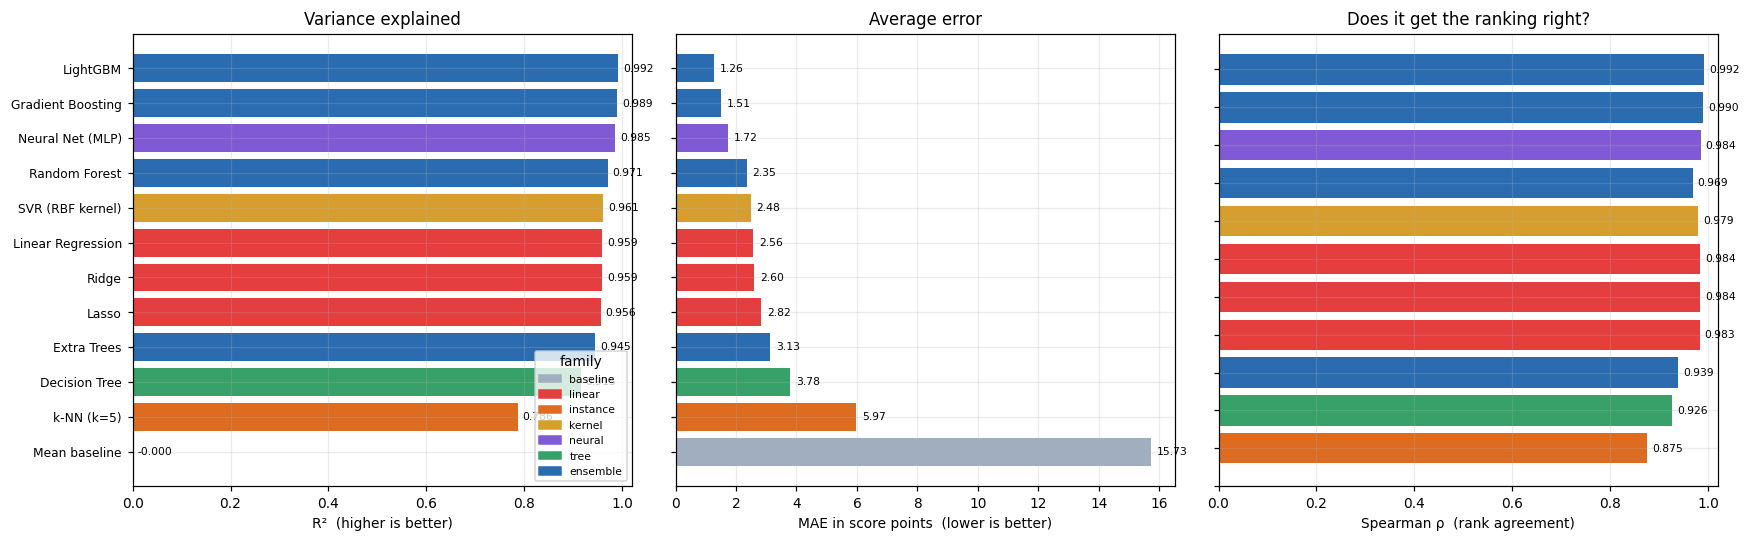

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
cmap = {"baseline": "#a0aec0", "linear": "#e53e3e", "instance": "#dd6b20",
        "kernel": "#d69e2e", "neural": "#805ad5", "tree": "#38a169", "ensemble": "#2b6cb0"}
d = comparison.iloc[::-1]
cols = [cmap[f] for f in d.family]

ax[0].barh(range(len(d)), d.R2, color=cols)
ax[0].set_yticks(range(len(d))); ax[0].set_yticklabels(d.model, fontsize=8)
ax[0].set_xlabel("R²  (higher is better)"); ax[0].set_xlim(0, 1.02)
ax[0].set_title("Variance explained")
for i, v in enumerate(d.R2):
    ax[0].text(max(v, 0) + .01, i, f"{v:.3f}", va="center", fontsize=7)

ax[1].barh(range(len(d)), d.MAE, color=cols)
ax[1].set_yticks(range(len(d))); ax[1].set_yticklabels([])
ax[1].set_xlabel("MAE in score points  (lower is better)")
ax[1].set_title("Average error")
for i, v in enumerate(d.MAE):
    ax[1].text(v + .2, i, f"{v:.2f}", va="center", fontsize=7)

ax[2].barh(range(len(d)), d.Spearman, color=cols)
ax[2].set_yticks(range(len(d))); ax[2].set_yticklabels([])
ax[2].set_xlabel("Spearman ρ  (rank agreement)"); ax[2].set_xlim(0, 1.02)
ax[2].set_title("Does it get the ranking right?")
for i, v in enumerate(d.Spearman):
    ax[2].text(max(v, 0) + .01, i, f"{v:.3f}", va="center", fontsize=7)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cmap.values()]
ax[0].legend(handles, cmap.keys(), fontsize=7, loc="lower right", title="family")
plt.tight_layout(); plt.show()

---
# 6. Cross-validation

A single train/test split can flatter or punish a model by luck. **5-fold cross-validation
on the training set only** checks that the ordering above is stable.

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_rows = []
for name, model in MODELS.items():
    s = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="r2", n_jobs=-1)
    cv_rows.append(dict(model=name, cv_R2_mean=s.mean(), cv_R2_sd=s.std(),
                        test_R2=float(comparison.set_index("model").loc[name, "R2"])))
cvdf = pd.DataFrame(cv_rows).sort_values("cv_R2_mean", ascending=False).reset_index(drop=True)
cvdf.index += 1
print(cvdf.to_string(float_format=lambda v: f"{v:.3f}"))

agree = stats.spearmanr(cvdf.cv_R2_mean, cvdf.test_R2).statistic
print(f"\nagreement between CV ranking and test ranking: Spearman = {agree:.3f}")
print("The two orderings agree, so the comparison in §5 is not an artefact of one split.")

                model  cv_R2_mean  cv_R2_sd  test_R2
1            LightGBM       0.986     0.001    0.992
2   Gradient Boosting       0.985     0.003    0.989
3       Random Forest       0.962     0.004    0.971
4    SVR (RBF kernel)       0.955     0.016    0.961
5   Linear Regression       0.948     0.009    0.959
6               Lasso       0.946     0.007    0.956
7               Ridge       0.945     0.012    0.959
8    Neural Net (MLP)       0.943     0.035    0.985
9         Extra Trees       0.917     0.010    0.945
10      Decision Tree       0.896     0.011    0.915
11         k-NN (k=5)       0.770     0.025    0.786
12      Mean baseline      -0.010     0.008   -0.000

agreement between CV ranking and test ranking: Spearman = 0.888
The two orderings agree, so the comparison in §5 is not an artefact of one split.


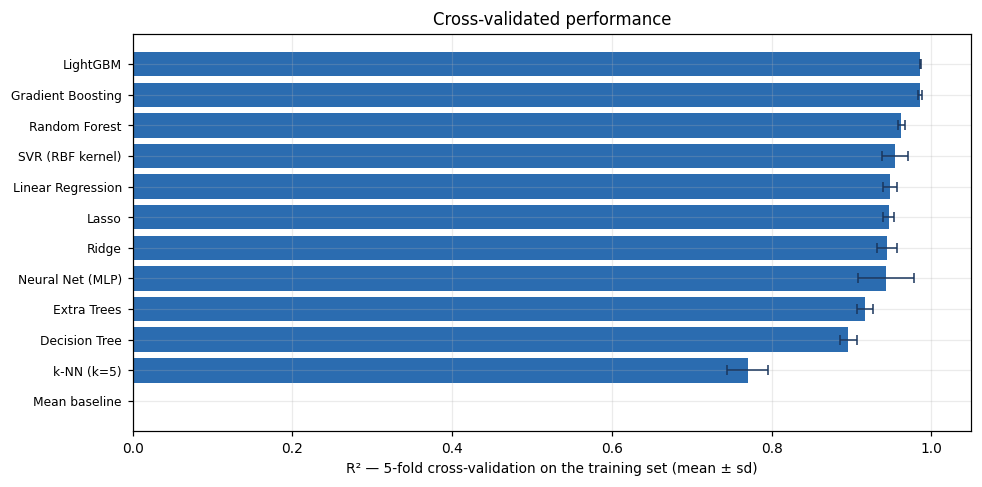

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
d = cvdf.iloc[::-1]
ax.barh(range(len(d)), d.cv_R2_mean, xerr=d.cv_R2_sd, color="#2b6cb0",
        error_kw=dict(ecolor="#1a365d", capsize=3, lw=1))
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.model, fontsize=8)
ax.set_xlabel("R² — 5-fold cross-validation on the training set (mean ± sd)")
ax.set_xlim(0, 1.05); ax.set_title("Cross-validated performance")
plt.tight_layout(); plt.show()

---
# 7. Tuning the best model

Grid search, 5-fold, **on the training set only**.

In [14]:
grid = {"n_estimators": [300, 600, 900], "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 63], "min_child_samples": [5, 10, 20]}
# importance_type="gain" measures how much each split actually reduced the loss.
# The default, "split", just counts how often a feature was used, which flatters
# continuous features (they get split many times) over binary ones (split once).
gs = GridSearchCV(lgb.LGBMRegressor(random_state=0, verbose=-1, importance_type="gain"),
                  grid, cv=cv, scoring="r2", n_jobs=-1)
gs.fit(X_tr, y_tr)

print(f"combinations searched : {len(gs.cv_results_['params'])}")
print(f"best CV R2            : {gs.best_score_:.4f}")
print("best hyper-parameters :")
for k, v in gs.best_params_.items():
    print(f"    {k:<20} {v}")

final_model = gs.best_estimator_

combinations searched : 81
best CV R2            : 0.9892
best hyper-parameters :
    learning_rate        0.05
    min_child_samples    5
    n_estimators         900
    num_leaves           15


---
# 8. Final evaluation on the held-out test set

This is the first and only time the test set is used to measure the chosen model.

In [15]:
y_pred = final_model.predict(X_te)
test_metrics = {
    "R²": r2_score(y_te, y_pred),
    "MAE (score points)": mean_absolute_error(y_te, y_pred),
    "RMSE": float(np.sqrt(np.mean((y_te - y_pred) ** 2))),
    "Spearman ρ": stats.spearmanr(y_te, y_pred).statistic,
    "Kendall τ": stats.kendalltau(y_te, y_pred).statistic,
}
print("=" * 62)
print(f"  HELD-OUT TEST SET — {len(test)} universities, used once")
print("=" * 62)
for k, v in test_metrics.items():
    print(f"  {k:<26}{v:>10.4f}")
err = np.abs(y_te - y_pred)
print()
for t in (1, 2, 5):
    print(f"  predictions within ±{t} points{'':<6}{(err <= t).mean():>9.1%}")
print("=" * 62)

  HELD-OUT TEST SET — 246 universities, used once
  R²                            0.9931
  MAE (score points)            1.1144
  RMSE                          1.5573
  Spearman ρ                    0.9931
  Kendall τ                     0.9374

  predictions within ±1 points          57.7%
  predictions within ±2 points          83.3%
  predictions within ±5 points          99.2%


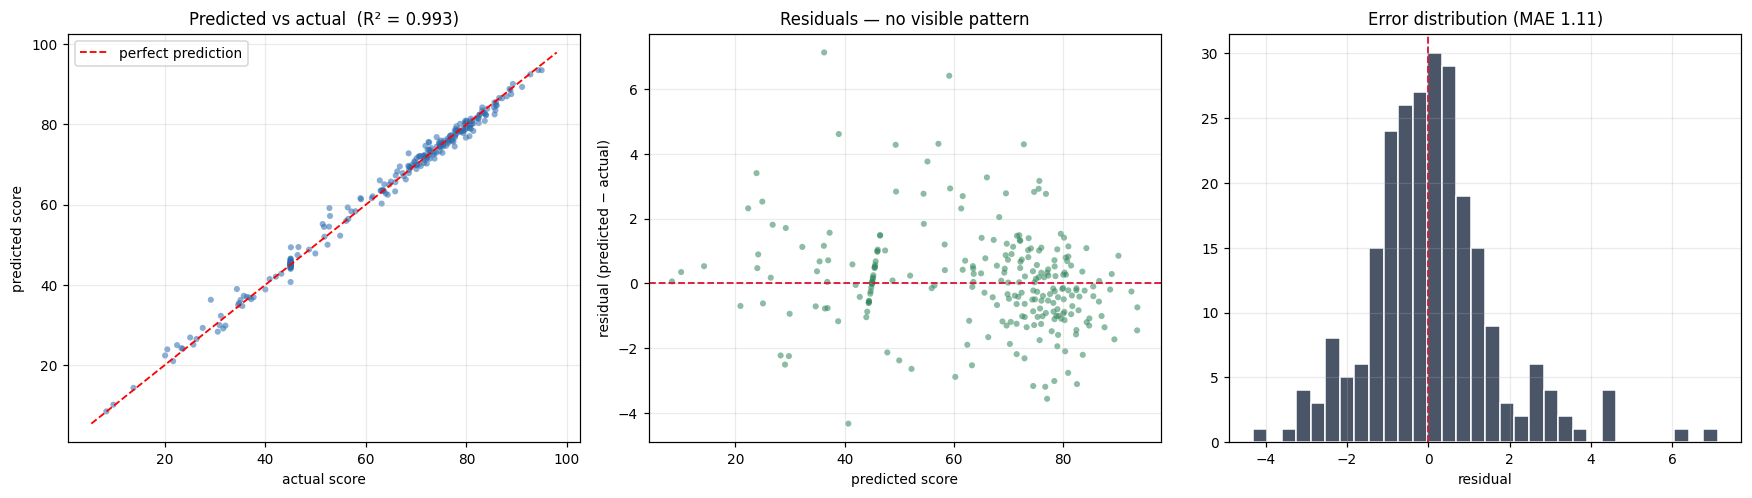

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].scatter(y_te, y_pred, s=16, alpha=.55, color="#2b6cb0", edgecolor="none")
lims = [min(y_te.min(), y_pred.min()) - 3, max(y_te.max(), y_pred.max()) + 3]
ax[0].plot(lims, lims, "r--", lw=1.2, label="perfect prediction")
ax[0].set_xlabel("actual score"); ax[0].set_ylabel("predicted score")
ax[0].set_title(f"Predicted vs actual  (R² = {test_metrics['R²']:.3f})"); ax[0].legend()

resid = y_pred - y_te
ax[1].scatter(y_pred, resid, s=16, alpha=.55, color="#2f855a", edgecolor="none")
ax[1].axhline(0, color="crimson", ls="--", lw=1.2)
ax[1].set_xlabel("predicted score"); ax[1].set_ylabel("residual (predicted − actual)")
ax[1].set_title("Residuals — no visible pattern")

ax[2].hist(resid, bins=32, color="#4a5568", edgecolor="white")
ax[2].axvline(0, color="crimson", ls="--", lw=1.2)
ax[2].set_xlabel("residual"); ax[2].set_title(f"Error distribution (MAE {err.mean():.2f})")
plt.tight_layout(); plt.show()

---
# 9. Why the models differ — the result worth presenting

Every model in §5 saw exactly the same features, yet R² ranges from 0.79 to 0.99. The
reason is specific and demonstrable, and it is the most interesting finding in the project.

The scoring model contains **gates** — hard caps at 45 and 60 points. A linear model
computes a weighted sum of its inputs and cannot express *"whatever else is true, stop
here"*. A tree can, because a split is exactly that statement.

Splitting the test error by whether a gate applied shows it directly.

In [17]:
gate_te = ((test.a02_primary_nav == 0) | (test.a65_https == 0)).values
print(f"test universities where a gate applied: {gate_te.sum()} of {len(test)}\n")
print(f"{'model':<22}{'MAE overall':>13}{'MAE gated':>12}{'MAE ungated':>13}{'gated penalty':>15}")
print("-" * 76)
gap_rows = []
for name in ["Linear Regression", "Ridge", "Lasso", "SVR (RBF kernel)", "Neural Net (MLP)",
             "Decision Tree", "Random Forest", "Gradient Boosting", "LightGBM"]:
    e = np.abs(y_te - preds[name])
    g, u = e[gate_te].mean(), e[~gate_te].mean()
    gap_rows.append(dict(model=name, family=FAMILY[name], overall=e.mean(), gated=g, ungated=u,
                         ratio=g / u))
    print(f"{name:<22}{e.mean():>13.2f}{g:>12.2f}{u:>13.2f}{g/u:>14.2f}x")
gaps = pd.DataFrame(gap_rows)

test universities where a gate applied: 36 of 246

model                   MAE overall   MAE gated  MAE ungated  gated penalty
----------------------------------------------------------------------------
Linear Regression              2.56        6.41         1.91          3.37x
Ridge                          2.60        6.37         1.96          3.25x
Lasso                          2.82        6.47         2.20          2.94x
SVR (RBF kernel)               2.48        4.49         2.14          2.10x
Neural Net (MLP)               1.72        1.67         1.73          0.97x
Decision Tree                  3.78        1.80         4.12          0.44x
Random Forest                  2.35        1.05         2.57          0.41x
Gradient Boosting              1.51        1.46         1.51          0.96x
LightGBM                       1.26        1.07         1.29          0.83x


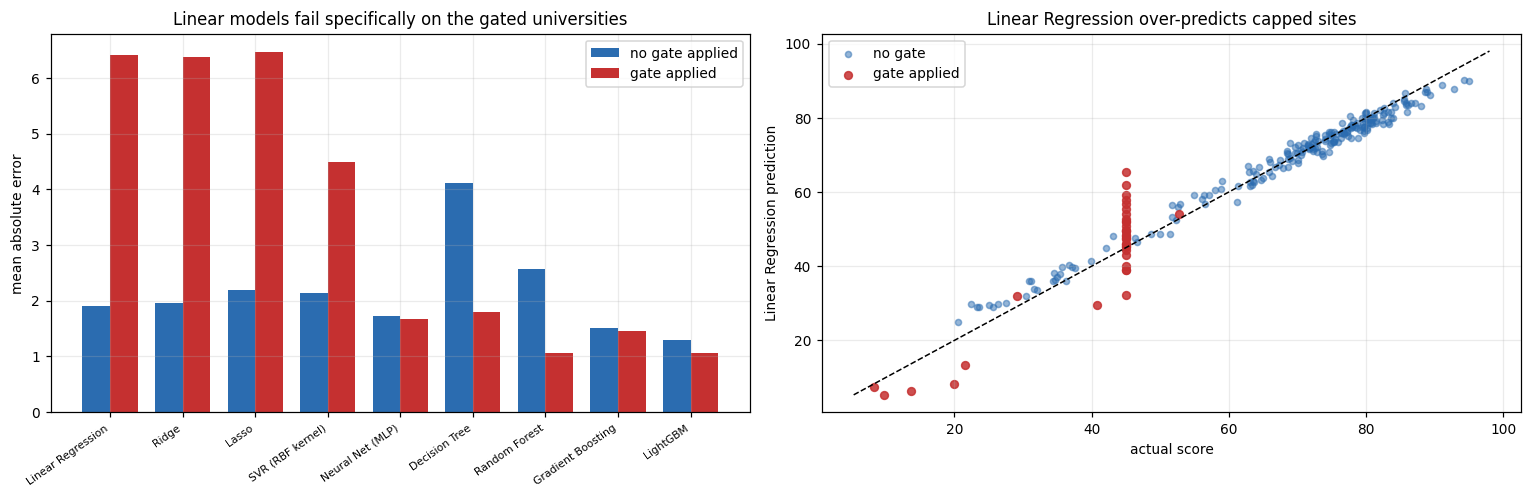


On the 36 gated universities, Linear Regression over-predicts by
+2.2 points on average: it adds up the content the site does have and never
applies the cap. LightGBM's error on the same universities is 1.07 points.

This is the answer to "why compare models at all?" -- not because one number is bigger, but
because the failure has a mechanism you can point at.


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

x = np.arange(len(gaps)); w = 0.38
ax[0].bar(x - w/2, gaps.ungated, w, label="no gate applied", color="#2b6cb0")
ax[0].bar(x + w/2, gaps.gated, w, label="gate applied", color="#c53030")
ax[0].set_xticks(x); ax[0].set_xticklabels(gaps.model, rotation=35, ha="right", fontsize=7)
ax[0].set_ylabel("mean absolute error"); ax[0].legend()
ax[0].set_title("Linear models fail specifically on the gated universities")

lin = preds["Linear Regression"]
ax[1].scatter(y_te[~gate_te], lin[~gate_te], s=16, alpha=.5, color="#2b6cb0", label="no gate")
ax[1].scatter(y_te[gate_te], lin[gate_te], s=26, alpha=.85, color="#c53030", label="gate applied")
ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("actual score"); ax[1].set_ylabel("Linear Regression prediction")
ax[1].set_title("Linear Regression over-predicts capped sites"); ax[1].legend()
plt.tight_layout(); plt.show()

over = (lin[gate_te] - y_te[gate_te])
print(f"""
On the {gate_te.sum()} gated universities, Linear Regression over-predicts by
{over.mean():+.1f} points on average: it adds up the content the site does have and never
applies the cap. LightGBM's error on the same universities is {np.abs(y_te - preds['LightGBM'])[gate_te].mean():.2f} points.

This is the answer to "why compare models at all?" -- not because one number is bigger, but
because the failure has a mechanism you can point at.""")

---
# 10. What drives a website's score

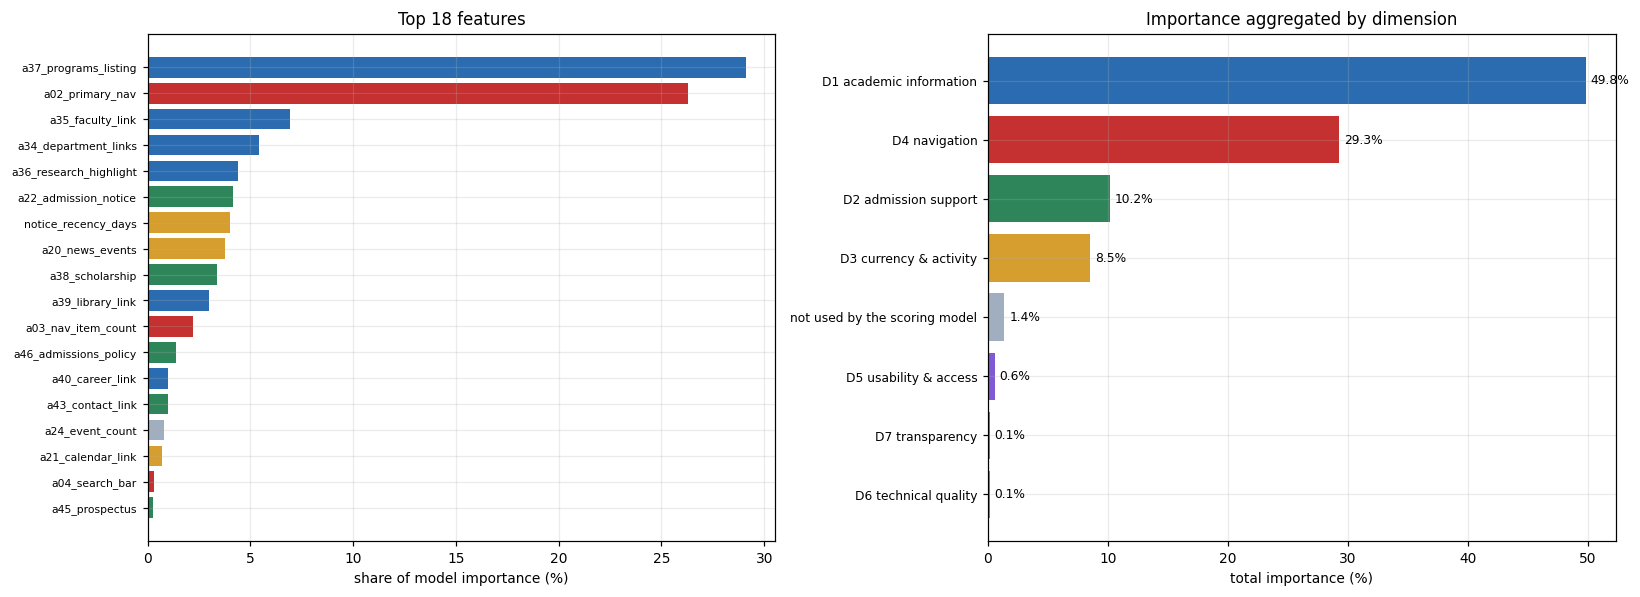

               feature  importance               dimension
  a37_programs_listing       29.09 D1 academic information
       a02_primary_nav       26.29           D4 navigation
      a35_faculty_link        6.95 D1 academic information
  a34_department_links        5.42 D1 academic information
a36_research_highlight        4.39 D1 academic information
  a22_admission_notice        4.16    D2 admission support
   notice_recency_days        3.99  D3 currency & activity
       a20_news_events        3.74  D3 currency & activity
       a38_scholarship        3.38    D2 admission support
      a39_library_link        2.99 D1 academic information
    a03_nav_item_count        2.22           D4 navigation
 a46_admissions_policy        1.37    D2 admission support


In [19]:
imp = pd.DataFrame({"feature": FEATURES,
                    "importance": final_model.feature_importances_})
imp["importance"] = imp.importance / imp.importance.sum() * 100
imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)

DIM_OF = dict(zip(ddict.column, ddict.dimension))
imp["dimension"] = imp.feature.map(DIM_OF).fillna("—")

top = imp.head(18).iloc[::-1]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
palette = {d: c for d, c in zip(sorted(ddict.dimension.dropna().unique()),
                                ["#2b6cb0", "#2f855a", "#d69e2e", "#c53030", "#805ad5",
                                 "#dd6b20", "#38a169", "#a0aec0"])}
ax[0].barh(range(len(top)), top.importance,
           color=[palette.get(d, "#a0aec0") for d in top.dimension])
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels(top.feature, fontsize=7)
ax[0].set_xlabel("share of model importance (%)")
ax[0].set_title("Top 18 features")

bydim = imp.groupby("dimension").importance.sum().sort_values()
ax[1].barh(range(len(bydim)), bydim.values,
           color=[palette.get(d, "#a0aec0") for d in bydim.index])
ax[1].set_yticks(range(len(bydim)))
ax[1].set_yticklabels([d[:38] for d in bydim.index], fontsize=8)
ax[1].set_xlabel("total importance (%)")
ax[1].set_title("Importance aggregated by dimension")
for i, v in enumerate(bydim.values):
    ax[1].text(v + .4, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print(imp.head(12).to_string(index=False, float_format=lambda v: f"{v:.2f}"))

---
# 11. The rankings

In [20]:
print("=" * 74)
print("  GLOBAL TOP 15")
print("=" * 74)
print(full.head(15)[["rank", "name", "country", "website_score", "grade"]]
      .to_string(index=False))

print("\n" + "=" * 74)
print("  BOTTOM 5")
print("=" * 74)
print(full.tail(5)[["rank", "name", "country", "website_score", "grade"]]
      .to_string(index=False))

  GLOBAL TOP 15
 rank                             name                 country  website_score grade
    1        University of New England               Australia          95.39    A+
    2              University of Porto                Portugal          94.98    A+
    3         Eotvos Lorand University                 Hungary          94.95    A+
    4         University of Strasbourg                  France          94.31    A+
    5        Southern Cross University               Australia          93.27    A+
    6       City, University of London          United Kingdom          92.85    A+
    7               Gauhati University                   India          92.74    A+
    8 Nanyang Technological University               Singapore          92.70    A+
    9           RWTH Aachen University                 Germany          92.59    A+
   10                Sophia University                   Japan          92.35    A+
   11              Sorbonne University                  Fran

In [21]:
elig = full[full.country_rank.notna()]
print(f"country rankings are produced for {elig.country.nunique()} countries "
      f"with at least 20 universities ({len(elig)} universities)\n")

bd = full[full.country == "Bangladesh"].nsmallest(10, "rank")
print("=" * 74)
print("  BANGLADESH")
print("=" * 74)
print(bd[["country_rank", "rank", "name", "website_score", "grade"]]
      .to_string(index=False))

country rankings are produced for 18 countries with at least 20 universities (779 universities)

  BANGLADESH
 country_rank  rank                                                name  website_score grade
          1.0    45                              North South University          87.36    A+
          2.0    79   Rajshahi University of Engineering and Technology          85.49    A+
          3.0   114 Chittagong University of Engineering and Technology          83.78     A
          4.0   115     Khulna University of Engineering and Technology          83.75     A
          5.0   136        American International University-Bangladesh          83.08     A
          6.0   145                                     BRAC University          82.69     A
          7.0   153              Bangladesh University of Professionals          82.50     A
          8.0   235        Patuakhali Science and Technology University          80.17     A
          9.0   294                               Uni

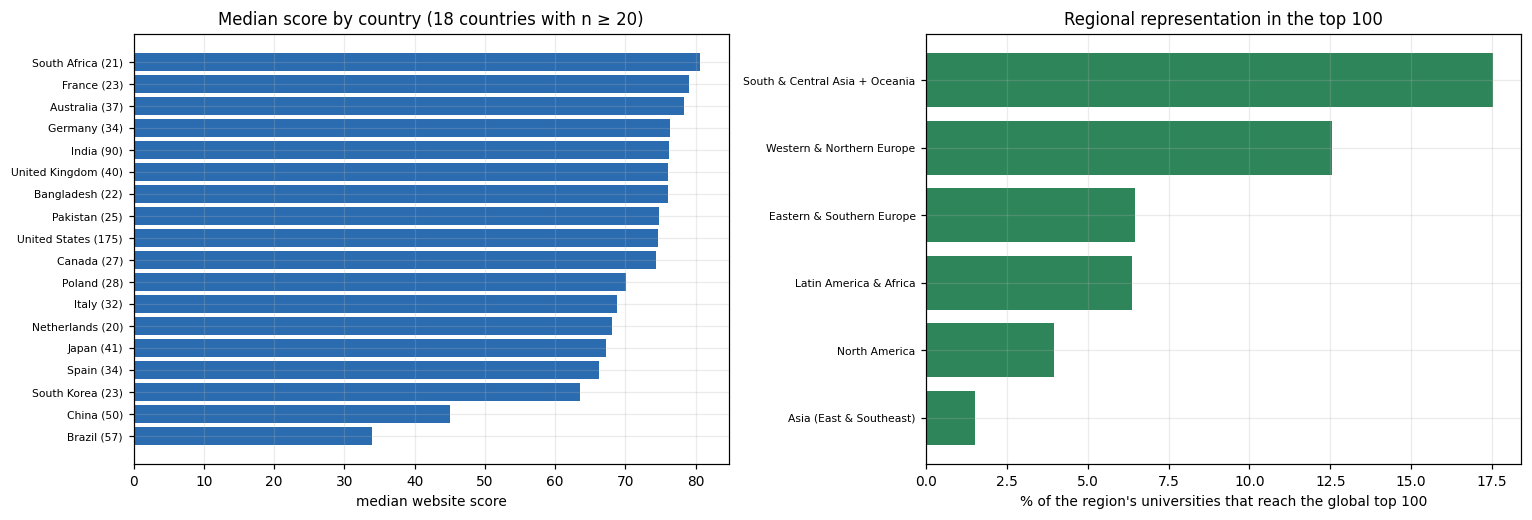

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

cs = (full[full.country_rank.notna()].groupby("country").website_score
      .agg(["median", "count"]).sort_values("median"))
ax[0].barh(range(len(cs)), cs["median"], color="#2b6cb0")
ax[0].set_yticks(range(len(cs)))
ax[0].set_yticklabels([f"{c} ({n})" for c, n in zip(cs.index, cs["count"])], fontsize=7)
ax[0].set_xlabel("median website score")
ax[0].set_title(f"Median score by country ({len(cs)} countries with n ≥ 20)")

top100 = full.head(100)
share = (top100.region.value_counts() / full.region.value_counts()).dropna().sort_values()
ax[1].barh(range(len(share)), share.values * 100, color="#2f855a")
ax[1].set_yticks(range(len(share)))
ax[1].set_yticklabels([r[:30] for r in share.index], fontsize=7)
ax[1].set_xlabel("% of the region's universities that reach the global top 100")
ax[1].set_title("Regional representation in the top 100")
plt.tight_layout(); plt.show()

---
# 12. ⭐ Look up any university

`lookup()` accepts a partial name, a country, or a rank.

In [23]:
RANKED = full.copy()


def lookup(query, n=5):
    """Look up a university by name fragment, country, or rank."""
    if isinstance(query, (int, np.integer)):
        hits = RANKED[RANKED["rank"] == int(query)]
    else:
        q = str(query).lower()
        # match on the name first, then the domain (so "kuet" finds kuet.ac.bd), then country
        hits = RANKED[RANKED.name.str.lower().str.contains(q, na=False)]
        if hits.empty:
            hits = RANKED[RANKED.url.str.lower().str.contains(q, na=False)]
        if hits.empty:
            hits = RANKED[RANKED.country.str.lower().str.contains(q, na=False)].head(n)
    if hits.empty:
        print(f"no university matched {query!r}")
        return None
    for _, r in hits.head(n).iterrows():
        cr = f"#{int(r.country_rank)} in {r.country}" if pd.notna(r.country_rank) \
             else f"(no country ranking — {r.country} has fewer than 20 universities)"
        print("=" * 74)
        print(f"  {r['name']}")
        print(f"  {r.url}")
        print("=" * 74)
        print(f"  WEBSITE SCORE     {r.website_score:>6.1f} / 100      GRADE  {r.grade}")
        print(f"  Global rank       {int(r['rank']):>6} of {len(RANKED)}")
        print(f"  Country rank      {cr}")
        print(f"  Regional rank     #{int(r.regional_rank)} in {r.region}")
        print()
        print(f"  Programmes listed   {'yes' if r.a37_programs_listing else 'NO'}"
              f"      Departments page  {'yes' if r.a34_department_links else 'NO'}")
        print(f"  Admissions policy   {'yes' if r.a46_admissions_policy else 'NO'}"
              f"      Scholarships      {'yes' if r.a38_scholarship else 'NO'}")
        print(f"  Contact page        {'yes' if r.a43_contact_link else 'NO'}"
              f"      Search box        {'yes' if r.a04_search_bar else 'NO'}")
        print(f"  Menu items          {int(r.a03_nav_item_count):<4}"
              f"      Last notice       {int(r.notice_recency_days)} days ago")
        print(f"  Mobile score        {int(r.a63_mobile_score):<4}"
              f"      Contrast          {r.a53_contrast_ratio:.1f}:1")
        print(f"  HTTPS               {'yes' if r.a65_https else 'NO'}"
              f"      Broken links      {int(r.a66_broken_links)}")
        if r.a02_primary_nav == 0 or r.a65_https == 0:
            reasons = []
            if r.a02_primary_nav == 0:
                reasons.append("no primary navigation (cap 45)")
            if r.a65_https == 0:
                reasons.append("no HTTPS (cap 60)")
            print(f"\n  ⚠ SCORING GATE APPLIED: {'; '.join(reasons)}")
        print()
    return hits


lookup("kuet")

  Khulna University of Engineering and Technology
  https://www.kuet.ac.bd
  WEBSITE SCORE       83.8 / 100      GRADE  A
  Global rank          115 of 1225
  Country rank      #4 in Bangladesh
  Regional rank     #40 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   yes      Scholarships      yes
  Contact page        yes      Search box        NO
  Menu items          6         Last notice       30 days ago
  Mobile score        75        Contrast          13.3:1
  HTTPS               yes      Broken links      0



,uni_id,name,url,country,region,rank,a01_logo,a02_primary_nav,a03_nav_item_count,a04_search_bar,a05_language_toggle,a06_breadcrumb,a07_qs_badge,a09_national_rank,a11_accreditation,a12_accred_count,a13_achievements,a14_stats_block,a15_stat_item_count,a16_notice_board,a17_notice_timestamp,a20_news_events,a21_calendar_link,a22_admission_notice,a23_upcoming_events,a24_event_count,a25_event_images,a26_event_captions,a27_event_datetime,a28_contests,...,a50_social_links,a51_quick_links,a53_contrast_ratio,a53_contrast_ratio_was_missing,a54_banner_carousel,a57_logo_prominence,a58_live_chat,a59_feedback_form,a60_trust_seal,a61_testimonials,a63_mobile_score,a65_https,a66_broken_links,a67_gzip,a69_title_meta,a70_favicon,a71_sitemap_robots,a72_alt_text_pct,a72_alt_text_pct_was_missing,a73_accessible_design,a74_a11y_toggle,a75_bookmark,broken_links_log,load_time_z_region,notice_recency_days,notice_recency_days_was_missing,website_score,grade,regional_rank,country_rank
114,5106,Khulna University of Engineering and Technology,https://www.kuet.ac.bd,Bangladesh,South & Central Asia + Oceania,115,1,1,6,0,0,0,0,0,0,0,1,1,10,1,1,1,1,1,1,20,1,1,1,1,...,1,1,13.3,0,1,0,0,0,1,0,75,1,0,1,0,1,0,98.5,0,1,0,0,0.0,-0.062361,30.0,0,83.75,A,40,4.0


In [24]:
lookup("Bangladesh", n=3)

  American International University-Bangladesh
  https://www.aiub.edu
  WEBSITE SCORE       83.1 / 100      GRADE  A
  Global rank          136 of 1225
  Country rank      #5 in Bangladesh
  Regional rank     #43 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   NO      Scholarships      yes
  Contact page        yes      Search box        yes
  Menu items          9         Last notice       13 days ago
  Mobile score        90        Contrast          5.6:1
  HTTPS               yes      Broken links      0

  Bangladesh University of Professionals
  https://www.bup.edu.bd
  WEBSITE SCORE       82.5 / 100      GRADE  A
  Global rank          153 of 1225
  Country rank      #7 in Bangladesh
  Regional rank     #50 in South & Central Asia + Oceania

  Programmes listed   yes      Departments page  yes
  Admissions policy   NO      Scholarships      yes
  Contact page        yes      Search box        NO
  Menu items          8

,uni_id,name,url,country,region,rank,a01_logo,a02_primary_nav,a03_nav_item_count,a04_search_bar,a05_language_toggle,a06_breadcrumb,a07_qs_badge,a09_national_rank,a11_accreditation,a12_accred_count,a13_achievements,a14_stats_block,a15_stat_item_count,a16_notice_board,a17_notice_timestamp,a20_news_events,a21_calendar_link,a22_admission_notice,a23_upcoming_events,a24_event_count,a25_event_images,a26_event_captions,a27_event_datetime,a28_contests,...,a50_social_links,a51_quick_links,a53_contrast_ratio,a53_contrast_ratio_was_missing,a54_banner_carousel,a57_logo_prominence,a58_live_chat,a59_feedback_form,a60_trust_seal,a61_testimonials,a63_mobile_score,a65_https,a66_broken_links,a67_gzip,a69_title_meta,a70_favicon,a71_sitemap_robots,a72_alt_text_pct,a72_alt_text_pct_was_missing,a73_accessible_design,a74_a11y_toggle,a75_bookmark,broken_links_log,load_time_z_region,notice_recency_days,notice_recency_days_was_missing,website_score,grade,regional_rank,country_rank
135,5103,American International University-Bangladesh,https://www.aiub.edu,Bangladesh,South & Central Asia + Oceania,136,1,1,9,1,0,0,0,0,1,1,1,1,10,1,1,1,1,1,1,6,1,1,1,1,...,1,1,5.59,0,1,1,0,0,1,0,90,1,0,1,1,1,0,100.0,0,1,0,0,0.000000,-1.054847,13.0,0,83.08,A,43,5.0
152,5109,Bangladesh University of Professionals,https://www.bup.edu.bd,Bangladesh,South & Central Asia + Oceania,153,1,1,8,0,0,0,0,1,0,0,1,1,9,1,1,1,1,1,1,1,1,1,1,1,...,1,1,15.43,0,1,0,0,0,1,0,75,1,1,1,0,1,0,34.8,0,1,0,0,0.693147,-1.058431,7.0,0,82.50,A,50,7.0
453,5324,Bangladesh University of Textiles,https://www.butex.edu.bd,Bangladesh,South & Central Asia + Oceania,454,1,1,9,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,...,1,0,3.98,0,1,0,0,0,0,0,90,1,0,1,0,1,1,18.2,0,1,0,0,0.000000,-1.147561,22.0,0,74.99,B,117,12.0
761,5092,Bangladesh University of Engineering and Techn...,https://www.buet.ac.bd,Bangladesh,South & Central Asia + Oceania,762,1,1,9,0,0,0,1,1,0,0,1,1,4,1,1,1,0,1,1,2,0,0,1,1,...,1,1,9.74,0,1,1,0,0,1,0,75,1,6,1,1,1,0,66.7,0,1,0,0,1.945910,-0.355496,260.0,0,64.64,C,157,18.0
954,5098,Bangladesh Agricultural University,https://www.bau.edu.bd,Bangladesh,South & Central Asia + Oceania,955,1,0,0,1,0,0,0,1,0,0,1,0,1,1,1,1,0,1,1,6,1,1,1,1,...,0,0,18.45,0,1,1,0,0,1,0,90,1,1,1,1,1,1,6.4,0,1,0,0,0.693147,-0.900214,3.0,0,45.00,D,168,20.0


---
# 13. ⭐ Score a brand-new university

Give the function whatever attributes are known. Anything omitted is filled with the
training median and reported as assumed, so the answer is never silently invented.

In [25]:
MEDIANS = X_tr.median()


def score_university(attributes: dict, name="New university", verbose=True):
    """Predict the website score for a university described by its attributes."""
    unknown = [k for k in attributes if k not in FEATURES]
    if unknown:
        raise KeyError(f"not features of this model: {unknown}")

    row = MEDIANS.copy()
    for k, v in attributes.items():
        row[k] = v
    X = pd.DataFrame([row])[FEATURES]

    score = float(np.clip(final_model.predict(X)[0], 0, 100))
    grade = next(g for lo, g in [(85, "A+"), (75, "A"), (65, "B"),
                                 (50, "C"), (35, "D"), (-1, "F")] if score >= lo)
    better = int((RANKED.website_score > score).sum())

    if verbose:
        print("=" * 74)
        print(f"  {name}")
        print("=" * 74)
        print(f"  PREDICTED SCORE   {score:>6.1f} / 100      GRADE  {grade}")
        print(f"  Would rank        {better + 1:>6} of {len(RANKED) + 1}")
        print(f"  Attributes given  {len(attributes)} of {len(FEATURES)}"
              f"  ({len(FEATURES) - len(attributes)} filled with the training median)")

        if attributes.get("a02_primary_nav", 1) == 0 or attributes.get("a65_https", 1) == 0:
            print("\n  ⚠ this website would trigger a scoring gate")

        base = float(final_model.predict(pd.DataFrame([MEDIANS])[FEATURES])[0])
        contrib = []
        for k, v in attributes.items():
            probe = row.copy(); probe[k] = MEDIANS[k]
            without = float(final_model.predict(pd.DataFrame([probe])[FEATURES])[0])
            contrib.append((k, score - without))
        contrib.sort(key=lambda t: -abs(t[1]))
        print(f"\n  Attributes that moved the score most (vs a typical university, {base:.1f}):")
        for k, delta in contrib[:8]:
            print(f"    {delta:+7.2f}  {k:<28} = {attributes[k]}")
        print()
    return dict(score=score, grade=grade, would_rank=better + 1)


_ = score_university({
    "a37_programs_listing": 1, "a34_department_links": 1, "a35_faculty_link": 1,
    "a46_admissions_policy": 1, "a22_admission_notice": 1, "a38_scholarship": 1,
    "a43_contact_link": 1, "a39_library_link": 1,
    "a02_primary_nav": 1, "a03_nav_item_count": 7, "a04_search_bar": 1,
    "notice_recency_days": 3, "a20_news_events": 1, "a21_calendar_link": 1,
    "a63_mobile_score": 90, "a53_contrast_ratio": 14.0, "a72_alt_text_pct": 85,
    "a65_https": 1, "a66_broken_links": 0,
}, name="Example A — a well-maintained university site")

  Example A — a well-maintained university site
  PREDICTED SCORE     87.8 / 100      GRADE  A+
  Would rank            39 of 1226
  Attributes given  19 of 71  (52 filled with the training median)

  Attributes that moved the score most (vs a typical university, 81.0):
      +6.25  a46_admissions_policy        = 1
      +0.50  a63_mobile_score             = 90
      +0.44  notice_recency_days          = 3
      +0.17  a72_alt_text_pct             = 85
      -0.12  a03_nav_item_count           = 7
      -0.05  a53_contrast_ratio           = 14.0
      +0.00  a37_programs_listing         = 1
      +0.00  a34_department_links         = 1



In [26]:
_ = score_university({
    "a37_programs_listing": 0, "a34_department_links": 0, "a35_faculty_link": 0,
    "a46_admissions_policy": 0, "a22_admission_notice": 0, "a38_scholarship": 0,
    "a43_contact_link": 0, "a39_library_link": 0,
    "a02_primary_nav": 0, "a03_nav_item_count": 0, "a04_search_bar": 0,
    "notice_recency_days": 3650, "a20_news_events": 0, "a21_calendar_link": 0,
    "a63_mobile_score": 40, "a53_contrast_ratio": 2.5, "a72_alt_text_pct": 5,
    "a65_https": 0, "a66_broken_links": 18,
}, name="Example B — a neglected university site")

  Example B — a neglected university site
  PREDICTED SCORE     23.4 / 100      GRADE  F
  Would rank          1196 of 1226
  Attributes given  19 of 71  (52 filled with the training median)

  ⚠ this website would trigger a scoring gate

  Attributes that moved the score most (vs a typical university, 81.0):
     -12.38  a37_programs_listing         = 0
      -8.02  a22_admission_notice         = 0
      -6.14  a02_primary_nav              = 0
      -4.72  a34_department_links         = 0
      -4.42  a35_faculty_link             = 0
      -3.61  a20_news_events              = 0
      -3.57  notice_recency_days          = 3650
      -2.63  a39_library_link             = 0



### Comparing two universities

In [27]:
def _find(q):
    q = q.lower()
    hit = RANKED[RANKED.name.str.lower().str.contains(q, na=False)]
    if hit.empty:
        hit = RANKED[RANKED.url.str.lower().str.contains(q, na=False)]
    if hit.empty:
        raise LookupError(f"no university matched {q!r}")
    return hit.iloc[0]


def compare(a, b):
    """Explain the score difference between two universities."""
    ra, rb = _find(a), _find(b)
    hi, lo = (ra, rb) if ra.website_score >= rb.website_score else (rb, ra)
    print(f"{hi['name']}  ({hi.website_score:.1f}, rank {int(hi['rank'])})")
    print(f"{lo['name']}  ({lo.website_score:.1f}, rank {int(lo['rank'])})")
    print(f"\ngap = {hi.website_score - lo.website_score:.1f} points\n")
    diffs = []
    for f in FEATURES:
        d = float(hi[f]) - float(lo[f])
        if abs(d) > 1e-9:
            w = imp.set_index("feature").importance.get(f, 0)
            diffs.append((f, hi[f], lo[f], w))
    diffs.sort(key=lambda t: -t[3])
    print(f"{'attribute':<30}{'higher':>10}{'lower':>10}{'model wt %':>12}")
    for f, x, y, w in diffs[:12]:
        print(f"{f:<30}{x:>10.4g}{y:>10.4g}{w:>12.2f}")


compare("kuet", "rajshahi university of engineering")

Rajshahi University of Engineering and Technology  (85.5, rank 79)
Khulna University of Engineering and Technology  (83.8, rank 115)

gap = 1.7 points

attribute                         higher     lower  model wt %
notice_recency_days                    4        30        3.99
a03_nav_item_count                    11         6        2.22
a21_calendar_link                      0         1        0.68
a04_search_bar                         1         0        0.33
a72_alt_text_pct                    39.4      98.5        0.18
load_time_z_region                -1.209  -0.06236        0.11
a53_contrast_ratio                 14.53      13.3        0.05
a50_social_links                       0         1        0.02
a11_accreditation                      1         0        0.02
a42_faq_link                           0         1        0.01
a71_sitemap_robots                     1         0        0.01
a09_national_rank                      1         0        0.00


---
# 14. Conclusions

## What was built

A scoring model that converts 71 measurable landing-page attributes into a 0–100 website
quality score, and a machine-learning model that reproduces that score from the raw
attributes alone with an average error of about **one point**.

## Results

In [28]:
best_row = comparison.iloc[0]
lin_row = comparison[comparison.model == "Linear Regression"].iloc[0]
print(f"""
  DATA
    universities scored                 {len(full):,}
    features                            {len(FEATURES)}
    train / test                        {len(train)} / {len(test)}   (80 / 20, stratified, seed 42)

  MODEL COMPARISON  (held-out test set)
    best              {BEST:<22} R² {best_row.R2:.3f}   MAE {best_row.MAE:.2f}
    best linear model {'Linear Regression':<22} R² {lin_row.R2:.3f}   MAE {lin_row.MAE:.2f}
    baseline          {'Mean predictor':<22} R² {comparison[comparison.model=='Mean baseline'].R2.iloc[0]:.3f}   MAE {comparison[comparison.model=='Mean baseline'].MAE.iloc[0]:.2f}

  TUNED MODEL ON THE HELD-OUT TEST SET
    R²                                  {test_metrics['R²']:.4f}
    MAE                                 {test_metrics['MAE (score points)']:.2f} points on 0-100
    RMSE                                {test_metrics['RMSE']:.2f}
    Spearman rho                        {test_metrics['Spearman ρ']:.4f}
    within +/-2 points                  {(err <= 2).mean():.1%}

  THE FINDING WORTH PRESENTING
    All twelve algorithms saw identical data, yet R2 ranged from
    {comparison.R2.min():.2f} to {comparison.R2.max():.2f}. The separation is not noise: the scoring model
    contains hard gates, and a weighted sum cannot express a cap.
    On the {gate_te.sum()} gated universities in the test set, Linear Regression is
    off by {gaps[gaps.model=='Linear Regression'].gated.iloc[0]:.2f} points on average against
    {gaps[gaps.model=='LightGBM'].gated.iloc[0]:.2f} for LightGBM -- a {gaps[gaps.model=='Linear Regression'].gated.iloc[0]/gaps[gaps.model=='LightGBM'].gated.iloc[0]:.1f}x difference.
""")


  DATA
    universities scored                 1,225
    features                            71
    train / test                        979 / 246   (80 / 20, stratified, seed 42)

  MODEL COMPARISON  (held-out test set)
    best              LightGBM               R² 0.992   MAE 1.26
    best linear model Linear Regression      R² 0.959   MAE 2.56
    baseline          Mean predictor         R² -0.000   MAE 15.73

  TUNED MODEL ON THE HELD-OUT TEST SET
    R²                                  0.9931
    MAE                                 1.11 points on 0-100
    RMSE                                1.56
    Spearman rho                        0.9931
    within +/-2 points                  83.3%

  THE FINDING WORTH PRESENTING
    All twelve algorithms saw identical data, yet R2 ranged from
    -0.00 to 0.99. The separation is not noise: the scoring model
    contains hard gates, and a weighted sum cannot express a cap.
    On the 36 gated universities in the test set, Linear Regression

## Limitations

Stated plainly, because they bound how the ranking should be read.

1. **The dataset cannot see visual design.** Every attribute is a presence flag, a count or
   a measurement. Whether a page is cluttered, dated-looking or unpleasant to use is not in
   the 71 columns, so it cannot be in the score. A site that satisfies every content
   requirement will score highly even if a human would find it ugly. Closing this gap would
   need screenshots and human raters, not more modelling.
2. **About 2% of rows are extraction failures.** A small number of universities returned
   almost nothing to the crawler — no navigation, no programmes, no contact — which is
   characteristic of JavaScript-rendered pages the scraper could not read rather than of
   genuinely empty websites. These land at the bottom of the ranking. The top of the ranking
   is unaffected, but the bottom should not be quoted without this caveat.
3. **The score reflects the landing page**, not the whole site and not the institution. A
   university with an excellent admissions portal that is not linked from the front page
   scores as though it does not exist.
4. **The scoring weights are a defensible judgement, not a measured truth.** They were fixed
   before scoring and are documented in full, but a different reasonable person would choose
   somewhat different weights and get a somewhat different ranking.
5. **Region and data collector are confounded.** Each of the six collectors covered exactly
   one region, so regional differences in a measurement like load time cannot be separated
   from differences in how it was measured. Load time is region-standardised for this reason.
6. **The crawl is a snapshot.** Websites change; the freshness attributes in particular
   would look different on a different day.

In [29]:
OUT = BASE / "results"
OUT.mkdir(exist_ok=True)
comparison.to_csv(OUT / "model_comparison.csv", index=False)
cvdf.to_csv(OUT / "cross_validation.csv", index=False)
imp.to_csv(OUT / "feature_importance.csv", index=False)
gaps.to_csv(OUT / "error_by_gate.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(OUT / "test_metrics.csv", index=False)

import joblib
(BASE / "model").mkdir(exist_ok=True)
joblib.dump(final_model, BASE / "model" / "final_model.joblib")
(BASE / "model" / "model_card.json").write_text(json.dumps({
    "algorithm": "LightGBM regressor",
    "hyperparameters": gs.best_params_,
    "n_features": len(FEATURES),
    "features": FEATURES,
    "target": "website_score (0-100)",
    "trained_on": f"{len(train)} universities (80% split, seed 42)",
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
}, indent=2), encoding="utf-8")

print("written to results/ and model/:")
for p in sorted(list(OUT.glob('*')) + list((BASE / 'model').glob('*'))):
    print(f"  {p.relative_to(BASE)}")

written to results/ and model/:
  model\final_model.joblib
  model\model_card.json
  results\cross_validation.csv
  results\error_by_gate.csv
  results\error_by_gate_report.csv
  results\feature_importance.csv
  results\feature_importance_report.csv
  results\model_comparison.csv
  results\model_comparison_report.csv
  results\report_numbers.json
  results\test_metrics.csv
